In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2 as cv

import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalMaxPool2D, Dropout ,BatchNormalization
from tensorflow.keras.models import Sequential , Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = '/kaggle/input/brain-mri-images-for-brain-tumor-detection'

In [4]:
filepaths = []
labels = []

folds = os.listdir(data)

for fold in folds:
    files = os.path.join(data , fold)
    filelist = os.listdir(files)
    for fpath in filelist:
        fillpath = os.path.join(files , fpath)

        filepaths.append(fillpath)
        labels.append(fold)

df = pd.DataFrame({'filepaths':filepaths , 'Labels':labels})

In [5]:
df

,filepaths,Labels
0,/kaggle/input/brain-mri-images-for-brain-tumor...,no
1,/kaggle/input/brain-mri-images-for-brain-tumor...,no
2,/kaggle/input/brain-mri-images-for-brain-tumor...,no
3,/kaggle/input/brain-mri-images-for-brain-tumor...,no
4,/kaggle/input/brain-mri-images-for-brain-tumor...,no
...,...,...
250,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
251,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
252,/kaggle/input/brain-mri-images-for-brain-tumor...,yes
253,/kaggle/input/brain-mri-images-for-brain-tumor...,brain_tumor_dataset


In [6]:
strat = df['Labels']

train, test = train_test_split(df , test_size = 0.2 , shuffle = True , random_state = 42 , stratify= strat)

In [7]:
img_size = 224
batch_size = 32
channels = 3

In [8]:
data_gen = ImageDataGenerator(rescale=1./255,)
                              

train_data = data_gen.flow_from_dataframe(train,
                                          x_col = 'filepaths',
                                          y_col = 'Labels',
                                          target_size = (img_size , img_size),
                                          batch_size=batch_size,
                                          class_mode = 'categorical',
                                          color_mode = 'rgb',
                                          shuffle = True)

test_data = data_gen.flow_from_dataframe(test,
                                         x_col = 'filepaths',
                                         y_col = 'Labels',
                                         target_size = (img_size , img_size),
                                         batch_size=batch_size,
                                         class_mode = 'categorical',
                                         color_mode = 'rgb',
                                         shuffle = False
                                         )

Found 202 validated image filenames belonging to 2 classes.
Found 51 validated image filenames belonging to 2 classes.


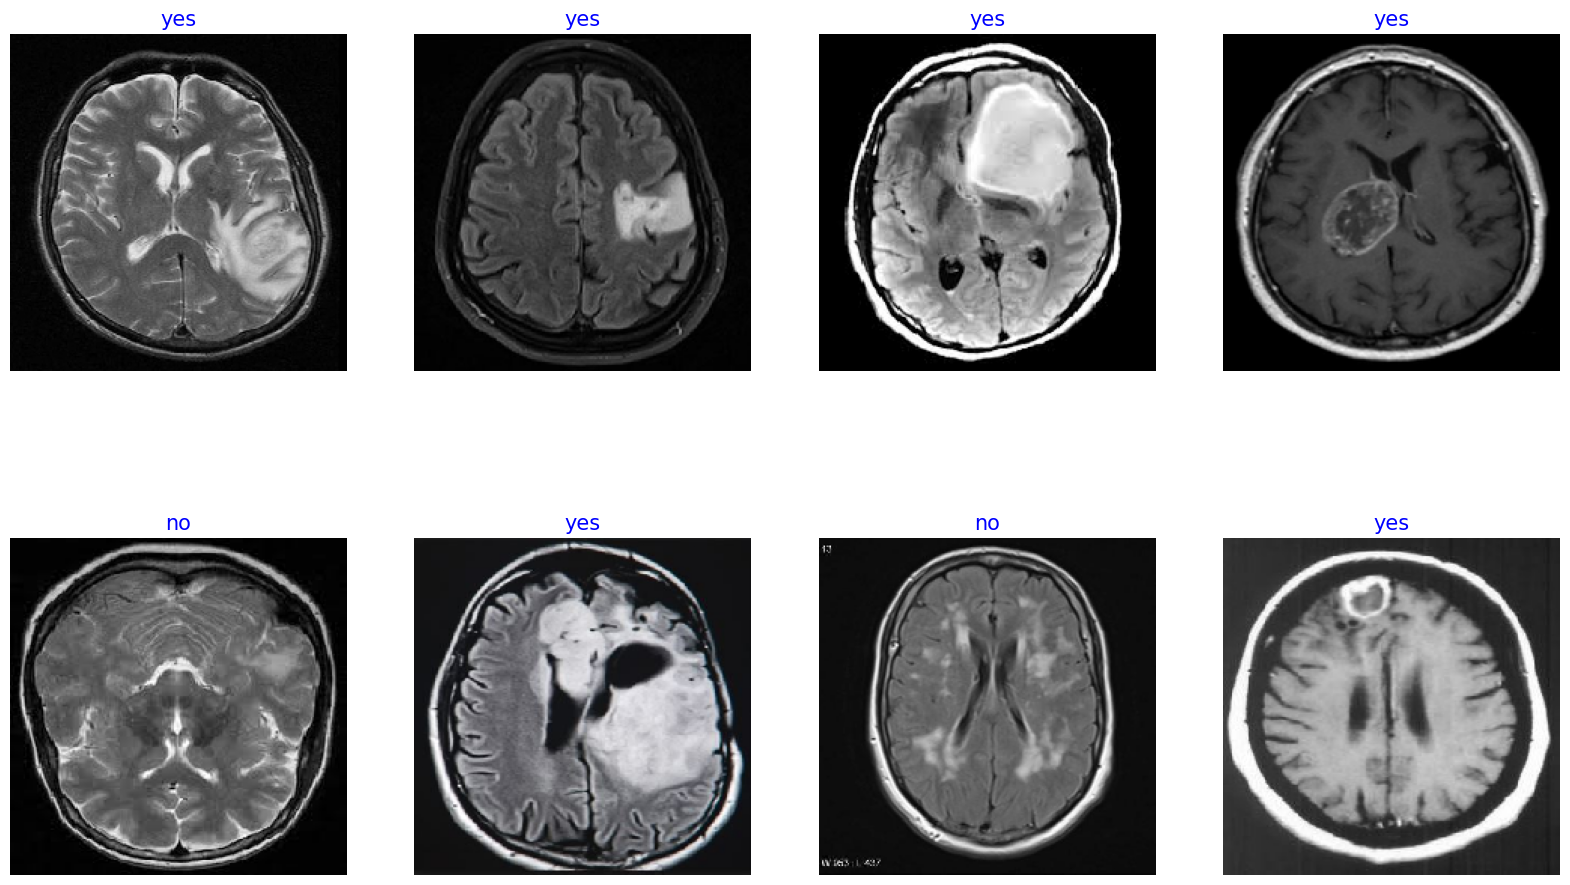

In [9]:
classes = train_data.class_indices      
classes = list(classes.keys())

images , labels = next(train_data)
plt.figure(figsize = (20,12))

for i in range(8):
    plt.subplot(2 , 4 , i+1)
    image = images[i]
    plt.imshow(image)

    label = np.argmax(labels[i])
    class_name = classes[label]
    plt.title(class_name, color= 'blue', fontsize= 15)
    plt.axis('off')
plt.show()
    

In [33]:
base_model = tf.keras.applications.ResNet50V2(input_shape = (img_size , img_size , channels) , include_top = False , weights = 'imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalMaxPool2D()(x)
x = Dense(256 , activation = 'relu')(x)
x = Dropout(0.3)(x)
x = Dense(64 , activation = 'relu')(x)
predictions = Dense(2 , activation = 'softmax')(x)

model_ResNet50V2 = Model(inputs = base_model.input , outputs = predictions)

In [34]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)

model_ResNet50V2.compile(optimizer = optimizer , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

In [35]:
from tensorflow.keras.callbacks import EarlyStopping
earlystop = EarlyStopping(patience=5, restore_best_weights=True , monitor='val_loss')

epochs = 20

history = model_ResNet50V2.fit(train_data,
                        epochs = epochs,
                        batch_size = batch_size,
                        validation_data = test_data,
                        callbacks = [earlystop])

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5175 - loss: 3.5996 - val_accuracy: 0.6078 - val_loss: 1.2040
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.6304 - loss: 1.6518 - val_accuracy: 0.6471 - val_loss: 0.6589
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.6552 - loss: 0.9478 - val_accuracy: 0.7255 - val_loss: 0.5421
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.7763 - loss: 0.6126 - val_accuracy: 0.6863 - val_loss: 0.5947
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.7758 - loss: 0.5667 - val_accuracy: 0.8431 - val_loss: 0.4434
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.8299 - loss: 0.4143 - val_accuracy: 0.8824 - val_loss: 0.4129
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.8708 - loss: 0.3734 - val_accuracy: 0.8824 - val_loss: 0.3934
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.9204 - loss: 0.2997 - val_accuracy: 0.9412 - val_loss: 0

In [38]:
loss , accuarcy = model_ResNet50V2.evaluate(test_data)
print(f'The Loss : {loss}')
print(f'The accuarcy : {accuarcy}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9165 - loss: 0.3716
The Loss : 0.37185972929000854
The accuarcy : 0.9215686321258545


In [44]:
train_score = model_ResNet50V2.evaluate(train_data, verbose= 1)
test_score = model_ResNet50V2.evaluate(test_data, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9586 - loss: 0.0938
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9165 - loss: 0.3716
Train Loss:  0.09459327161312103
Train Accuracy:  0.9603960514068604
--------------------
Test Loss:  0.37185972929000854
Test Accuracy:  0.9215686321258545


In [63]:
preds = model_ResNet50V2.predict(test_data)
y_pred = np.argmax(preds, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step


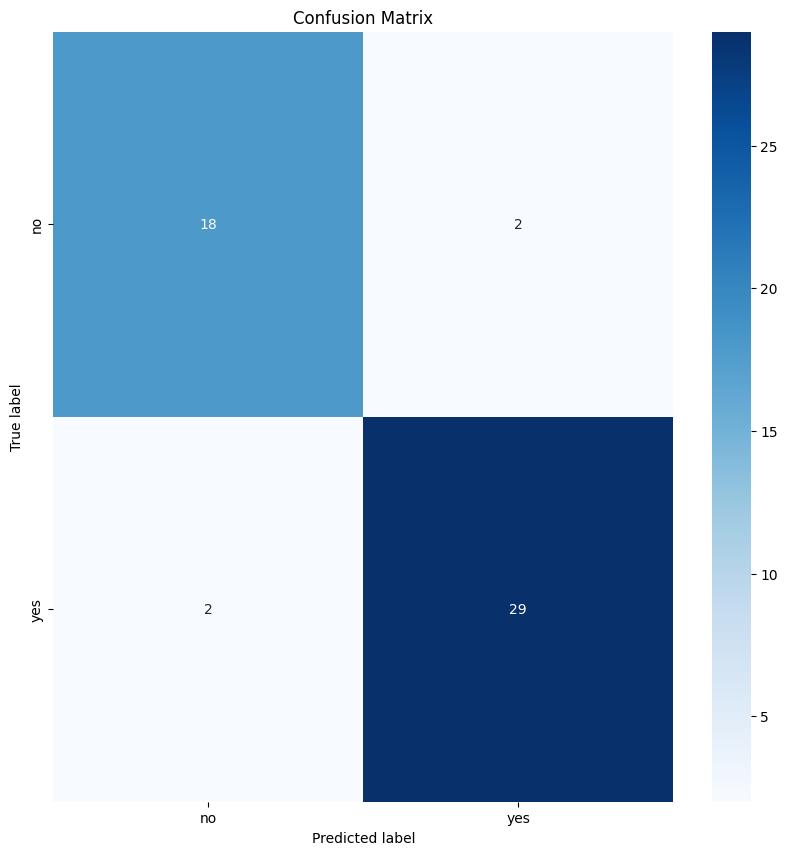

In [73]:
g_dict = test_data.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize= (10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [82]:
print(classification_report(test_data.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

          no       0.90      0.90      0.90        20
         yes       0.94      0.94      0.94        31

    accuracy                           0.92        51
   macro avg       0.92      0.92      0.92        51
weighted avg       0.92      0.92      0.92        51



In [39]:
model_ResNet50V2.save('brain_tumor_classifier.keras')

In [40]:
from IPython.display import FileLink
FileLink('brain_tumor_classifier.keras')

/kaggle/working/brain_tumor_classifier.keras

In [135]:
def prediction(img_path):
    img = tf.keras.utils.load_img(img_path , target_size=(img_size, img_size))
    img = tf.keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0) / 255.0
    
    predictions = model_ResNet50V2.predict(img)
    predicted_class = np.argmax(predictions[0])
    print(f"Predicted probabilities: {np.max(predictions[0])*100:.2f}% for {classes[predicted_class]}")

    plt.figure(figsize = (8 , 5))
    plt.subplot(1 , 2 , 1)
    sns.barplot(x=classes, y=predictions[0], palette= 'Set3')
    
    plt.xlabel('Classes')
    plt.ylabel('Probability')

    plt.subplot(1 , 2 , 2)
    plt.imshow(img[0])
    plt.title('Input Image')

    plt.tight_layout()
    plt.show()


In [138]:
img_path = '/kaggle/input/brain-mri-images-for-brain-tumor-detection/no/34 no.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted probabilities: 96.03% for no


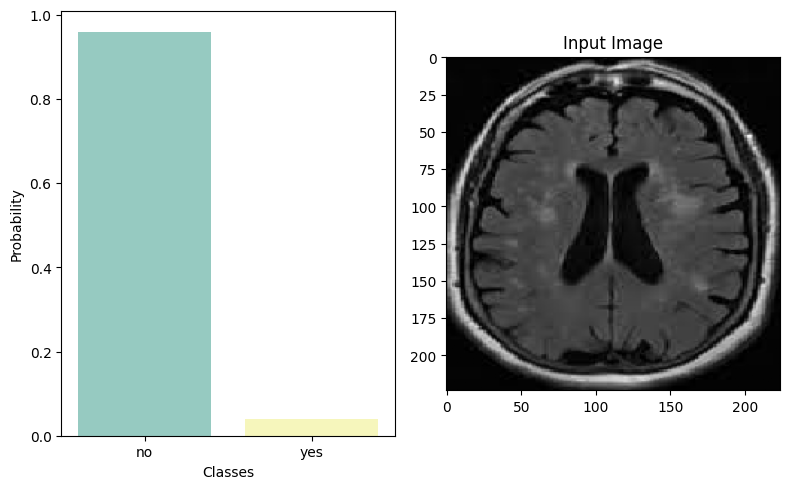

In [139]:
prediction(img_path)